## A short notebook tutorial on Gaussian Process Regression w/ SuperMAG data

*Last Modified*: Aug 12th, 2024

Author: [Opal Issan](https://opaliss.github.io/opalissan/) (PhD student @UCSD). contact: oissan@ucsd.edu

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np 
import scipy
import cartopy.crs as ccrs
from supermag_api import * 
import GPy
from IPython.display import display
from scipy.stats import pearsonr
from sec import T_df, get_mesh, remove_duplicate_lonlat
import stripy
from spherical_harmonics import get_spherical_harmonic_basis_matrix, ridge_regression, construct_global_view

In [3]:
import matplotlib.pyplot as plt
import matplotlib
from mycolorpy import colorlist as mcp
font = {'family' : 'serif',
        'size'   : 14}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 

## SuperMAG data

In [4]:
# start date year-month-day-hour-min-sec
# St. Patricks Day Storm
# May storm 202405120000
start=[2024, 5, 12, 0, 0, 0] 

In [5]:
# read in data
(status,stations) = SuperMAGGetInventory("opaliss", start, 3600)
# number of stations
N = len(stations)
print("number of stations = ", N)

number of stations =  175


In [6]:
# intialize data
data_Bn = np.zeros(N)
data_Be = np.zeros(N)
data_Bz = np.zeros(N)
geo_lat = np.zeros(N)
geo_lon = np.zeros(N)

In [7]:
# # read in data for 1hr in advance from start date at station "res"
# # note: this is very slow.. not sure if there are faster ways to go about this
# kk=0
# for ii in range(0, N):
#     (status, sm_data) = SuperMAGGetData("opaliss", start, 3600, 'geo', stations[ii])
#     try:
#         if sm_data.glat[0] not in geo_lat and sm_data.glon[0] not in geo_lon:
#             data_Bn[kk] = sm_data.N[0]["geo"]
#             data_Be[kk] = sm_data.E[0]["geo"]
#             data_Bz[kk] = sm_data.Z[0]["geo"]
#             geo_lat[kk] = sm_data.glat[0]
#             geo_lon[kk] = sm_data.glon[0]
#             kk+=1
#     except:
#         print("An exception occurred at " + str(stations[ii]))

In [8]:
# data_Bn = data_Bn[:kk]
# data_Be = data_Be[:kk]
# data_Bz = data_Bz[:kk]
# geo_lat = geo_lat[:kk]
# geo_lon = geo_lon[:kk]

In [9]:
data_Bn = np.load("data/Bn.npy")
data_Be = np.load("data/Be.npy")
data_Bz = np.load("data/Bz.npy")
geo_lat = np.load("data/geo_lat.npy")
geo_lon = np.load("data/geo_lon.npy")

## 2D regression *without* spherical harmonic assumption 
#### radial basis function kriging: squared exponential

\begin{aligned}x&=r\sin \theta \,\cos \varphi ,\\y&=r\sin \theta \,\sin \varphi ,\\z&=r\cos \theta .\end{aligned}



In [10]:
def spherical_to_cartesian(latitude, longitude, radius=6371):
    x = radius * np.sin(latitude*np.pi/180) * np.cos(longitude*np.pi/180)
    y = radius * np.sin(latitude*np.pi/180) * np.sin(longitude*np.pi/180)
    z = radius * np.cos(latitude*np.pi/180)
    return np.array([x, y, z])

In [11]:
# sample inputs and outputs
X = spherical_to_cartesian(latitude=geo_lat+90, longitude=geo_lon, radius=6371)
Y = np.reshape(data_Bn, (len(data_Bn), 1))

In [12]:
def great_circle(lon1, lat1, lon2, lat2):
    # in km
    return 6371 * (np.acos(np.sin(lat1*np.pi/180) * np.sin(lat2*np.pi/180) + np.cos(lat1*np.pi/180) * np.cos(lat2*np.pi/180) * np.cos(lon1*np.pi/180 - lon2*np.pi/180)))

In [13]:
# setup kernel + its hyperparameters
kernel = GPy.kern.RBF(input_dim=3, variance=1., lengthscale=1.)

In [14]:
# create simple GP model
m = GPy.models.GPRegression(X.T, Y,kernel)
# optimize
# m.Gaussian_noise.constrain_bounded(1, 200)
m.optimize(messages=True, max_f_eval = 100)

Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s02  0003   1.847563e+06   2.761250e+11 
    00s05  0007   5.454754e+05   2.632444e+09 
    00s11  0016   4.422197e+04   1.052982e+05 
    00s16  0024   3.383170e+03   6.107982e+00 
    00s19  0028   2.103122e+03   1.290566e-01 
    00s29  0050   1.477083e+03   1.595690e-11 
Runtime:     00s29
Optimization status: Converged



In [15]:
m

GP_regression.,value,constraints,priors
rbf.variance,44667.652765406856,+ve,
rbf.lengthscale,865.5011506835859,+ve,
Gaussian_noise.variance,3213.236316847518,+ve,


In [16]:
# location of prediction mesh grid
N_pred = 700
TT, PP = np.meshgrid(np.linspace(0, 180, N_pred, endpoint=False), 
                     np.linspace(0, 360, N_pred, endpoint=False))

XX, YY, ZZ = spherical_to_cartesian(latitude=TT, longitude=PP, radius=6371)

In [17]:
A, B = m.predict(Xnew=np.array([np.ndarray.flatten(XX, "C"), 
                                np.ndarray.flatten(YY, "C"), 
                                np.ndarray.flatten(ZZ, "C")]).T)

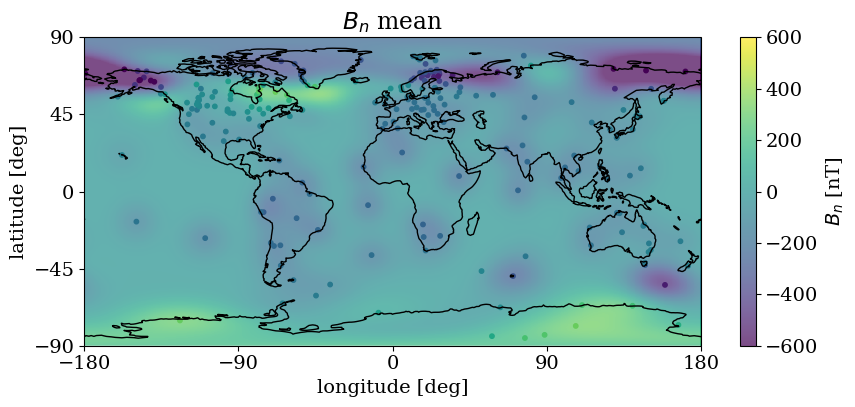

In [18]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(PP, TT-90, np.reshape(A, (N_pred, N_pred)),
                    alpha=0.7, transform=ccrs.PlateCarree(), vmin=-600, vmax=600, shading="nearest")

plt.scatter(geo_lon, geo_lat, c=data_Bn, s=10, cmap='viridis', vmin=-600, vmax=600, transform=ccrs.PlateCarree())
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ mean")
#ax.set_xlim(-180, 180)
#ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/mean_rbf.png", bbox_inches='tight', dpi=600)

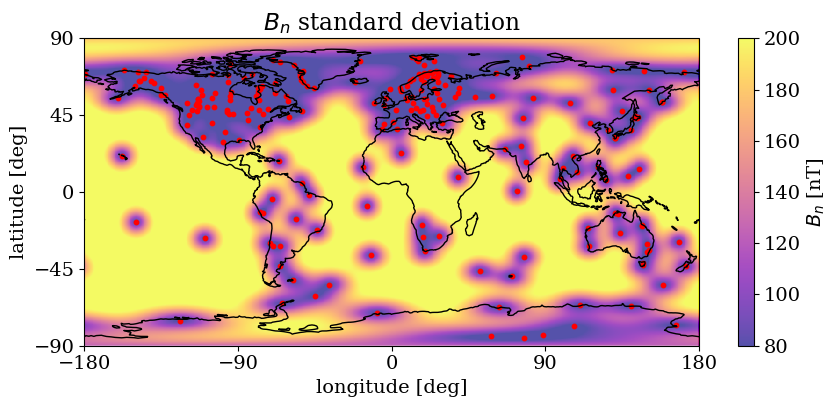

In [19]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(PP, TT-90, np.reshape(np.sqrt(B), (N_pred, N_pred)), alpha=0.7, transform=ccrs.PlateCarree(),
                    cmap="plasma", shading="nearest", vmin=80, vmax=200)

plt.scatter(geo_lon, geo_lat, s=10, c='red')
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ standard deviation")
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/std_rbf.png", bbox_inches='tight', dpi=600)

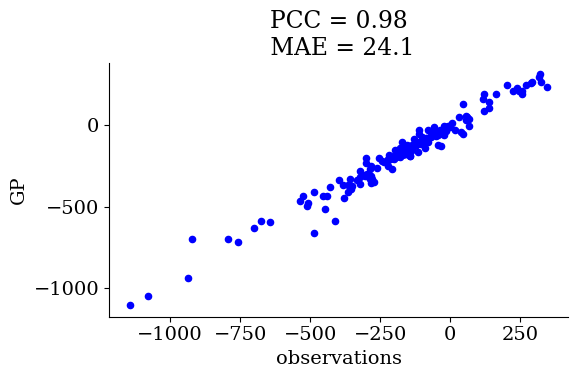

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))

corr, _ = pearsonr(Y[:, 0], m.predict(Xnew=X.T)[0][:, 0])
mae = np.mean(np.abs(Y[:, 0]- m.predict(Xnew=X.T)[0][:, 0]))

ax.scatter(Y, m.predict(Xnew=X.T)[0], label="GP", color="blue", s=20)
ax.set_title("PCC = " + str(round(corr, 2)) + "\n MAE = " + str(round(mae, 2)))
ax.set_xlabel("observations")
ax.set_ylabel("GP")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/rbf_error.png", dpi=600)

## 2D Regression *with* Spherical Harmonic assumption 

In [21]:
# sample inputs and outputs
ell = 10
X = get_spherical_harmonic_basis_matrix(latitude=(geo_lat+90)*np.pi/180, longitude=geo_lon*np.pi/180, ell=ell)
Y = np.reshape(data_Bn, (len(data_Bn), 1))

In [22]:
# setup kernel + its hyperparameters
kernel = GPy.kern.Linear(input_dim=(ell+1)**2, variances=1)

In [23]:
np.shape(X)

(238, 121)

In [24]:
# create simple GP model
m = GPy.models.GPRegression(X, Y,kernel)
# optimize
#m.Gaussian_noise.constrain_bounded(1, 200)
m.optimize(messages=True, max_f_eval = 10000)

Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s03  0004   4.731814e+05   1.300003e+10 
    00s04  0006   2.582932e+05   1.283537e+09 
    00s09  0014   2.780462e+04   1.571661e+05 
    00s14  0023   3.253069e+03   6.094655e+00 
    00s22  0039   1.529238e+03   5.888981e-11 
Runtime:     00s22
Optimization status: Converged



In [25]:
m

GP_regression.,value,constraints,priors
linear.variances,7831.085081970238,+ve,
Gaussian_noise.variance,13500.55183667186,+ve,


In [26]:
# location of prediction mesh grid
N_pred = 700
XX, YY = np.meshgrid(np.linspace(0, 180, N_pred, endpoint=False), 
                     np.linspace(0, 360, N_pred, endpoint=False))

X_pred = get_spherical_harmonic_basis_matrix(latitude=np.ndarray.flatten(XX, "C")*np.pi/180, 
              
                                             longitude=np.ndarray.flatten(YY, "C")*np.pi/180, 
                                             ell=ell)

In [27]:
A, B = m.predict(Xnew=X_pred)

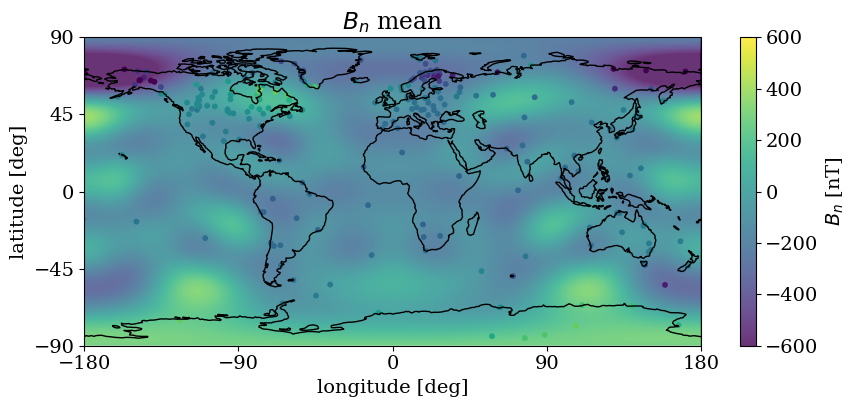

In [28]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(YY, XX-90, np.reshape(A, (N_pred, N_pred), "C"), alpha=0.8, 
                    transform=ccrs.PlateCarree(), vmin=-600, vmax=600)
plt.scatter(geo_lon, geo_lat, c=data_Bn, s=10, cmap='viridis', vmin=-600, vmax=600, transform=ccrs.PlateCarree())

cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ mean")
#ax.set_xlim(-180, 180)
#ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/mean_sph_linear.png", bbox_inches='tight', dpi=600)

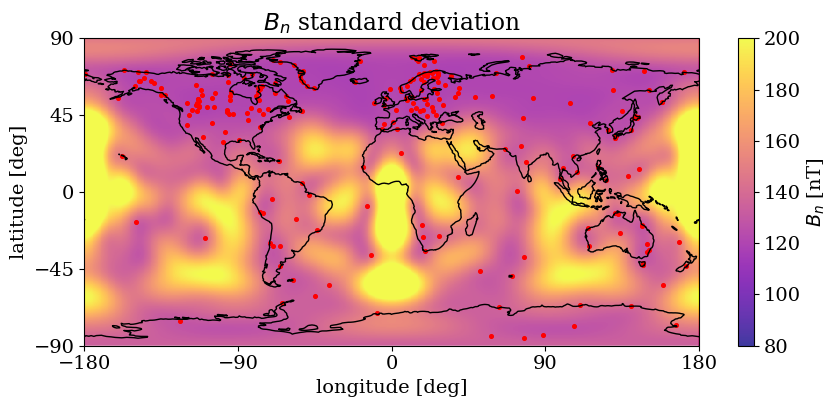

In [29]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(YY, XX-90, np.reshape(np.sqrt(B), (N_pred, N_pred), "C"), 
                    alpha=0.8, transform=ccrs.PlateCarree(), cmap="plasma", shading="nearest", vmin=80, vmax=200)

plt.scatter(geo_lon, geo_lat, c="red", s=7)
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ standard deviation")
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/std_sph_linear.png", bbox_inches='tight', dpi=600)

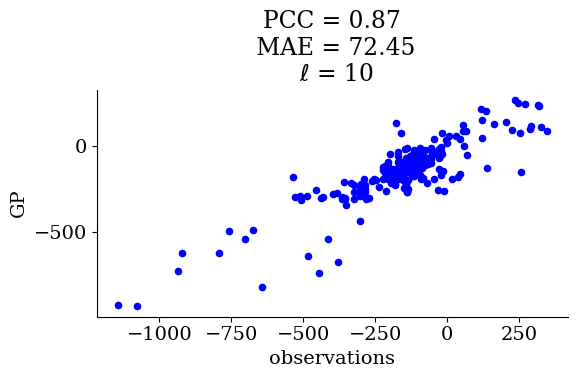

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))


y_pred = m.predict(Xnew=X)[0][:, 0]
corr, _ = pearsonr(Y[:, 0], y_pred)
mae = np.mean(np.abs(Y[:, 0] - y_pred))

ax.scatter(Y, y_pred, label="GP", color="blue", s=20)
ax.set_title("PCC = " + str(round(corr, 2)) + "\n MAE = " + str(round(mae, 2)) + "\n $\ell$ = " + str(ell))
ax.set_xlabel("observations")
ax.set_ylabel("GP")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/rbf_error_ell_" + str(ell) + ".png", dpi=600)

## 2D Regression *with* Spherical Elementary Currents (SECs) assumption including Bz

In [31]:
R_earth = 6371  # in km
R_ionosphere = R_earth + 100  # in km

In [32]:
def remove_duplicate_lonlat(lon, lat):
    """
    remove duplicates from an array of lon / lat points
    """

    a = np.ascontiguousarray(np.vstack((lon, lat)).T)
    unique_a = np.unique(a.view([('', a.dtype)]*a.shape[1]))
    llunique = unique_a.view(a.dtype).reshape((unique_a.shape[0], a.shape[1]))

    lon1 = llunique[:,0]
    lat1 = llunique[:,1]

    return lon1, lat1

In [33]:
lon, lat = remove_duplicate_lonlat(lon=geo_lon, lat=geo_lat)
mesh = stripy.sTriangulation(lon, lat)

In [34]:
mesh_lat = mesh.lats * 180/np.pi
mesh_lon = (mesh.lons * 180/np.pi + 180)

In [35]:
# specify the secs grid
lat_sec, lon_sec, r_sec = lat_sec, lon_sec, r_sec = mesh_lat,  mesh_lon, R_ionosphere * np.ones(len(mesh_lat))  # in km
secs_lat_lon_r = np.hstack((lat_sec.reshape(-1, 1), lon_sec.reshape(-1, 1), r_sec.reshape(-1, 1)))

In [36]:
# specify the observed grid
obs_lat_lon_r = np.vstack((geo_lat, geo_lon, R_earth*np.ones(len(geo_lon)))).T

In [37]:
# observations in a vector
B_obs = np.append(np.append(data_Bn, data_Be), data_Bz)
B_obs = np.reshape(B_obs, (len(B_obs), 1))

In [38]:
# get T matrix
T_mat = T_df(obs_loc=obs_lat_lon_r, sec_loc=secs_lat_lon_r)
np.shape(T_mat)

(714, 237)

In [39]:
# setup kernel + its hyperparameters
kernel = GPy.kern.Linear(input_dim=np.shape(T_mat)[1], variances=1)

In [40]:
# create simple GP model
m = GPy.models.GPRegression(T_mat, B_obs,kernel)
# restrict the Gaussian noise to something reasonable
m.Gaussian_noise.constrain_bounded(0, 200)
# optimize 
m.optimize(messages=True, max_f_eval = 100)

reconstraining parameters GP_regression.Gaussian_noise


Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s17  0006   3.939673e+05   1.061416e+11 
    01s30  0054   1.830047e+04   3.447639e-11 
Runtime:     01s30
Optimization status: Converged



In [41]:
m

GP_regression.,value,constraints,priors
linear.variances,259787224.9167719,+ve,
Gaussian_noise.variance,200.0,"0.0,200.0",


In [42]:
# predicted grid
n_lat, n_lon = 200, 200
pred_lat_lon_r, pred_lat, pred_lon = get_mesh(n_lon=n_lon, n_lat=n_lat, radius=R_earth,
                                              lat_max=90, lat_min=-90, endpoint_lon=False)

In [43]:
# predict
A, B = m.predict(Xnew=T_df(obs_loc=pred_lat_lon_r, sec_loc=secs_lat_lon_r))

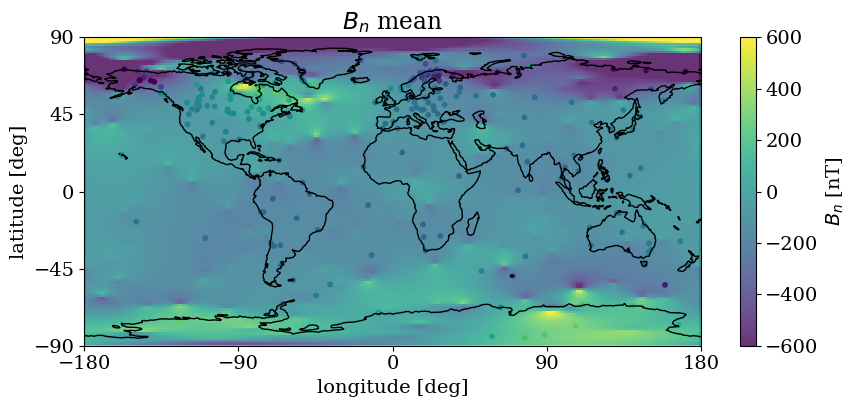

In [44]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(pred_lon[:, :, 0], pred_lat[:, :, 0], np.reshape(A[:n_lat*n_lon], (n_lat, n_lon), "C"), alpha=0.8, 
                    transform=ccrs.PlateCarree(), vmin=-600, vmax=600, shading="nearest")
plt.scatter(geo_lon, geo_lat, c=data_Bn, s=10, cmap='viridis', vmin=-600, vmax=600, transform=ccrs.PlateCarree())

cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ mean")
#ax.set_xlim(-180, 180)
#ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/mean_sec_linear.png", bbox_inches='tight', dpi=600)

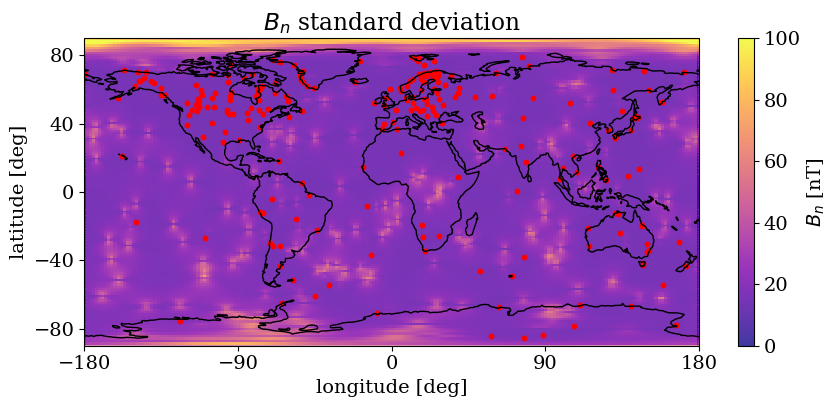

In [45]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())


ax.coastlines()
pos = ax.pcolormesh(pred_lon[:, :, 0], pred_lat[:, :, 0], np.reshape(np.sqrt(B)[:n_lat*n_lon], (n_lat, n_lon), "C"), alpha=0.8, 
                    transform=ccrs.PlateCarree(), vmin=0, vmax=100, cmap="plasma", shading="nearest")
plt.scatter(geo_lon, geo_lat, s=10, c='red', transform=ccrs.PlateCarree())

plt.scatter(geo_lon, geo_lat, c="red", s=7)
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-80, -40, 0, 40, 80])
ax.set_title("$B_{n}$ standard deviation")
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/std_sec_linear.png", bbox_inches='tight', dpi=600)

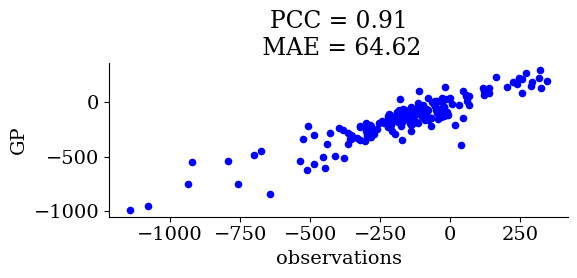

In [46]:
fig, ax = plt.subplots(figsize=(6, 3))


y_pred = m.predict(Xnew=T_mat)[0][:, 0][: len(obs_lat_lon_r)]
corr, _ = pearsonr(Y[:, 0], y_pred)
mae = np.mean(np.abs(Y[:, 0] - y_pred))

ax.scatter(Y, y_pred, label="GP", color="blue", s=20)
ax.set_title("PCC = " + str(round(corr, 2)) + "\n MAE = " + str(round(mae, 2)))
ax.set_xlabel("observations")
ax.set_ylabel("GP")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/sec_error.png", dpi=600)

## 2D Regression *with* Spherical Elementary Currents (SECs) assumption NOT including Bz

In [47]:
# observations in a vector
B_obs = np.append(data_Bn, data_Be)
B_obs = np.reshape(B_obs, (len(B_obs), 1))

In [48]:
# setup the SECs "node" grid
# n_lon and n_lat are free parameters but are limited to n_lon*n_lat ~ number of stations
lon, lat = remove_duplicate_lonlat(lon=geo_lon, lat=geo_lat)
mesh = stripy.sTriangulation(lon * np.pi/180 - np.pi*0.9, lat*np.pi/180, refinement_levels=0)
mesh_lat = mesh.lats * 180/np.pi
mesh_lon = (mesh.lons * 180/np.pi + 180)

# specify the secs grid
lat_sec, lon_sec, r_sec = lat_sec, lon_sec, r_sec = mesh_lat,  mesh_lon, R_ionosphere * np.ones(len(mesh_lat))  # in km
secs_lat_lon_r = np.hstack((lat_sec.reshape(-1, 1), lon_sec.reshape(-1, 1), r_sec.reshape(-1, 1)))

In [49]:
# get T matrix
T_mat = T_df(obs_loc=obs_lat_lon_r, sec_loc=secs_lat_lon_r, include_Bz=False)
np.shape(T_mat)

(476, 237)

In [50]:
# setup kernel + its hyperparameters
kernel = GPy.kern.Linear(input_dim=np.shape(T_mat)[1], variances=1)

In [51]:
# create simple GP model
m = GPy.models.GPRegression(T_mat, B_obs,kernel)
# restrict the Gaussian noise to something reasonable
m.Gaussian_noise.constrain_bounded(0, 200)
# optimize 
m.optimize(messages=True, max_f_eval = 100)

reconstraining parameters GP_regression.Gaussian_noise


Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s13  0011   5.953049e+04   6.000728e+07 
    00s15  0013   5.372324e+04   3.751939e+06 
    00s18  0015   5.227068e+04   2.345285e+05 
    00s49  0053   1.017427e+04   5.037493e-11 
Runtime:     00s49
Optimization status: Converged



In [52]:
m

GP_regression.,value,constraints,priors
linear.variances,210774342.09969252,+ve,
Gaussian_noise.variance,200.0,"0.0,200.0",


In [53]:
# predicted grid
n_lat, n_lon = 200, 200
pred_lat_lon_r, pred_lat, pred_lon = get_mesh(n_lon=n_lon, n_lat=n_lat, radius=R_earth,
                                              lat_max=90, lat_min=-90, endpoint_lon=False)

In [69]:
# predict
A, B = m.predict(Xnew=T_df(obs_loc=pred_lat_lon_r, sec_loc=secs_lat_lon_r, include_Bz=False))

In [70]:
np.shape(A)

(80000, 1)

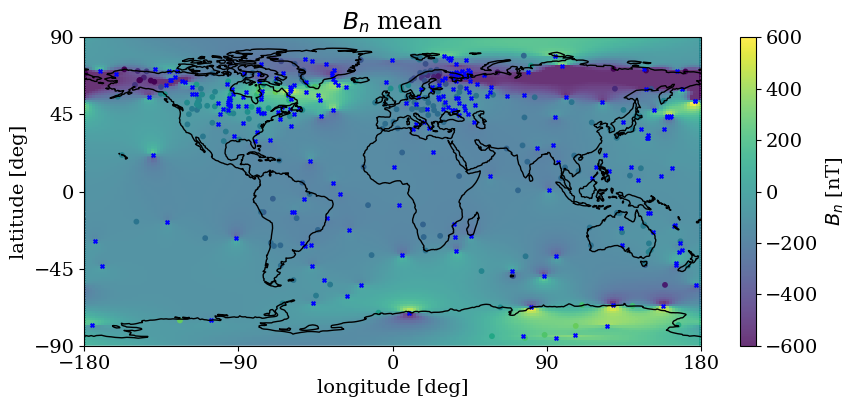

In [71]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(pred_lon[:, :, 0], pred_lat[:, :, 0], np.reshape(A[:n_lat*n_lon], (n_lat, n_lon), "C"), alpha=0.8, 
                    transform=ccrs.PlateCarree(), vmin=-600, vmax=600)
plt.scatter(geo_lon, geo_lat, c=data_Bn, s=10, cmap='viridis', vmin=-600, vmax=600, transform=ccrs.PlateCarree())
ax.scatter(mesh_lon, mesh_lat, c="blue", s=7, marker="x")
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ mean")
#ax.set_xlim(-180, 180)
#ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/mean_sec_linear_not.png", bbox_inches='tight', dpi=600)

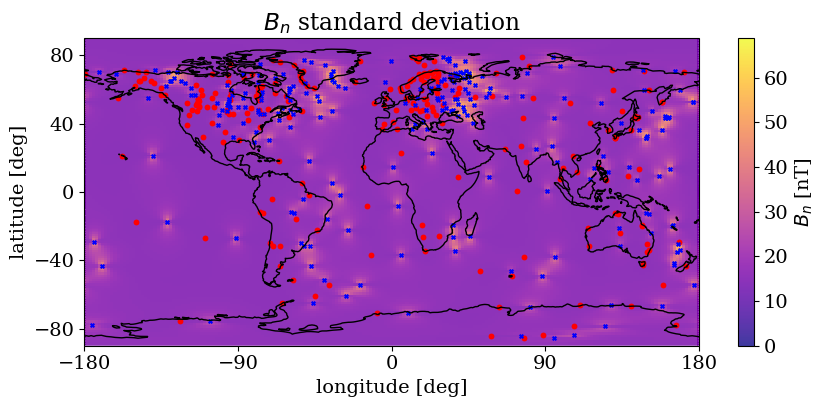

In [72]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())


ax.coastlines()
pos = ax.pcolormesh(pred_lon[:, :, 0], pred_lat[:, :, 0], np.reshape(np.sqrt(B)[:n_lat*n_lon], (n_lat, n_lon), "C"), alpha=0.8, 
                    transform=ccrs.PlateCarree(), vmin=0, cmap="plasma", shading="nearest")
plt.scatter(geo_lon, geo_lat, s=10, c='red', transform=ccrs.PlateCarree())

plt.scatter(geo_lon, geo_lat, c="red", s=7)
ax.scatter(mesh_lon, mesh_lat, c="blue", s=7, marker="x")
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-80, -40, 0, 40, 80])
ax.set_title("$B_{n}$ standard deviation")
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/std_sec_linear_not.png", bbox_inches='tight', dpi=600)

In [118]:
kk=0
for ii in np.arange(0, 360, 2):
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_longitude=ii, central_latitude=60))

    plt.style.use('dark_background')
    ax.coastlines()
    pos = ax.pcolormesh(pred_lon[:, :, 0], pred_lat[:, :, 0], np.reshape(A[:n_lat*n_lon], (n_lat, n_lon), "C"),
                       alpha=0.8, transform=ccrs.PlateCarree(), vmin=-500, vmax=500)
    plt.scatter(geo_lon, geo_lat, c=data_Bn, s=3, cmap='viridis', transform=ccrs.PlateCarree(), vmin=-500, vmax=500)

    cbar = fig.colorbar(pos, orientation="horizontal")
    cbar.ax.set_ylabel("[nT]", rotation=90)
    ax.gridlines(alpha=0.9, ls="--", color="white")

    _ = plt.title("mean $B_{n}$")
    ax.scatter(0, 0, s=2)
    ax.set_xlabel("longitude [deg]")
    ax.set_ylabel("latitude [deg]")
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()


    plt.savefig("figures/image_" + str(kk) + ".png", bbox_inches='tight', dpi=600)
    plt.close()
    kk+=1

In [120]:
kk=0
for ii in np.arange(0, 360, 2):
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_latitude=60))

    plt.style.use('dark_background')
    ax.coastlines()
    pos = ax.pcolormesh(pred_lon[:, :, 0], pred_lat[:, :, 0], np.reshape(np.sqrt(B)[:n_lat*n_lon], (n_lat, n_lon), "C"),
                       alpha=0.8, cmap="plasma", transform=ccrs.PlateCarree())
    plt.scatter(geo_lon, geo_lat, s=2, c='red', transform=ccrs.PlateCarree())

    cbar = fig.colorbar(pos, orientation="horizontal")
    cbar.ax.set_ylabel("[nT]", rotation=90)

    ax.gridlines(alpha=0.9, ls="--", color="white")
    _ = plt.title("standard deviation $B_{n}$")
    ax.scatter(0, 0, s=2)
    ax.set_xlabel("longitude [deg]")
    ax.set_ylabel("latitude [deg]")
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()

    plt.savefig("figures/image_sd_" + str(kk)+ ".png", bbox_inches='tight', dpi=600)
    plt.close()
    kk+=1